<a href="https://colab.research.google.com/github/AlijaY69/mlfhvl/blob/main/solutions_merged_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vectorial Word Representations

## Background
Representing words as dense vectors over a finite-dimensional space was one of the recent breakthroughs in Natural Language Processing. Vectorial representations allow space-efficient, informationally rich storage of words that adequately captures their semantic content and enables numerical computation on them. Word vectors are the standard input representation for machine learning architectures for language processing. Even though new methods for constructing such representations emerge frequently, the original set of published papers remain a de facto point of reference as well as a good starting point. For this assignment, you will be asked to implement a small-scale variant of one such paper, namely [Global Word Vectors for Word Representation](https://nlp.stanford.edu/pubs/glove.pdf) ("the GloVe paper").

Notes on the paper will appear throughout the notebook to guide you along the code. It is, however, important to read and understand the paper, its terminology and the theory behind it before attempting to go through with the assignment. Some of the tasks will also require addressing the paper directly.

---

There are 2 types of tasks in this assignment:
- coding tasks --- asking you to write code following specifications provided; Most of the tasks come with test cases for sanity-check. Still, if something is not clear, <ins>do ask questions to lab teachers</ins>. When working with tensors, you have to use tensor-related operations instead of, e.g., inefficiently looping through tensor rows and columns.
- interpretation questions --- asking you to interpret the data or the results of the model

Each comes with its predefined points (totaling to 50pt). Some coding tasks have 0 points but solving them will be useful for you.

---

You are greatly encouraged to add comments to your code describing what particular lines of code do (in general, a great habit to have in your coding life).
Additionally please follow these rules when submitting the notebook:

* Put all code in the cell with the `# YOUR CODE HERE` comment.
* Use torch operators when processing tensors (e.g., don't iterate over tensor elements)
* For theoretical questions, put your solution in the `YOUR ANSWER HERE` cell and keep the header(!).
* Don't change or delete any initially provided cells, either text or code, unless explicitly instructed to do so.
* Don't delete the comment lines `# TEST...` or edit their code cells. The test cells are for sanity checking. Passing them doesn't necessarily means that your code is fine.
* Don't change the names of provided functions and variables or arguments of the functions.
* Don't clear the output of your code cells.
* Don't output unnecessary info (e.g., printing variables for debugging purposes). This clutters the notebook and slows down the grading. You can have print() in the code, but comment them out before submitting the notebook.
* Delete those cells that you inserted for your own debuging/testing purposes.
* Don't forget to fill in the contribution information.
* Test your code and **make sure we can run your notebook** in the colab environment.
* A single notebook file (without archiving) per group should be submitted via BB.

<font color="red">You following these rules helps us to grade the submissions relatively efficiently. If these rules are violated, a submission will be subject to penalty points.</font>


# <font color="red">Contributions</font>

### Group Members

*   Ali Ostowar
*   Konstantinos Mereos
*   Yifan Zhou

### Contributions

We each completed all the exercises individually to gain a solid understanding of the material, discussed the challenging parts together, and helped each other throughout the process. In the end, we divided the final merging task, combining our work from three different Google Colab notebooks into one:

Yifan Zhou - Merged the parts from `From Co-occurrence to Probabilities`.

Ali Ostowar - Merged the parts from `Dense Vectors`.

Konstantinos Mereos - Merged the parts from `Analysis of Most Similar Words in the Harry Potter Corpus`.



## Corpus Statistics

The paper's proposed model, GloVe, aims to densely represent words in a way that captures the global corpus statistics.

The construction it encodes is the word __co-occurrence matrix__. A co-occurrence matrix is a simplistic data structure that counts the number of times each word has appeared within the context of every other word. The definition of a context varies; usually, context is implied to be a fixed-length span (that may or may not be allowed to escape sentence boundaries) around a word.

For instance, in the sentence below and for a context length of 2, the word <span style="color:pink">__Earth__</span> occurs in the context of <span style="color:lightgreen">made</span> (1), <span style="color:lightgreen">on</span> (1), <span style="color:lightgreen">as</span> (1), <span style="color:lightgreen">an</span> (1).

> "He struck most of the friends he had <span style="color:lightgreen">made on</span> <span style="color:pink">__Earth__</span> <span style="color:lightgreen">as an</span> eccentric"

Similarly, the word <span style="color:pink">__friends__</span> occurs in the context of <span style="color:lightgreen">of</span> (1), <span style="color:lightgreen">the</span> (1), <span style="color:lightgreen">he</span> (1), <span style="color:lightgreen">had</span> (1).

> "He struck most <span style="color:lightgreen">of the</span> <span style="color:pink">__friends__</span> <span style="color:lightgreen">he had</span> made on Earth as an eccentric"

An alternative definition of a context would be, for instance, the variable-length windows spanned by a full sentence.

Contexts may be summed across sentences or entire corpora; the summed context of <span style="color:pink">__he__</span> in the example sentence is: <span style="color:lightgreen">struck</span> (1), <span style="color:lightgreen">most</span> (1), <span style="color:lightgreen">the</span> (1), <span style="color:lightgreen">friends</span> (1), <span style="color:lightgreen">had</span> (1), <span style="color:lightgreen">made</span> (1).



For the purposes of this assignment, we have prepared a co-occurrence matrix over a minimally processed version of the Harry Potter books.

(A few interpretation tasks in this assignment presuppose some minimal level of familiarity with the Harry Potter books/films. If no one in your group is familiar with Harry Potter, you might find the [fandom page](https://harrypotter.fandom.com/wiki/Main_Page) useful or the [synopsis sections](https://en.wikipedia.org/wiki/Harry_Potter_and_the_Philosopher%27s_Stone) of the corresponding wiki pages.

The pickle file contains three items:
1. `vocab`: a dictionary mapping words to unique ids, containing $N$ unique words
2. `contexts`: a dictionary mapping words to their contexts, where contexts are themselves dicts from words to integers that show the number of co-occurrences between these words.
    E.g. `{"portrait": {"harry": x, "said": y, ...}, ...}` meaning that the word "harry" has appeared in the context of the word "portrait" $x$ times, etc.
3. `X`: a torch LongTensor ${X}$ of size $N \times N$, where ${X}[i,j]$ denotes the number of times the word with id $j$ has appeared in the context of the word with id $i$

Extremely common or uncommon words (i.e. words with too few or too many global occurrences) have been filtered out for practical reasons.

In [ ]:
import pickle, math
import torch
from torch import FloatTensor, LongTensor
from typing import Dict, Callable, List
# torch.set_printoptions(precision=8) #to increase precision of printing floats

In [ ]:
# this command downloads the pickle file.
# This is not a python code, it is a unix code. You can run system commands in jupyter notebooks.
!wget -nv -O HP-Counts-25.zip https://naturallogic.pro/_files_/download/MLHVL/HP-Counts-25.zip
!unzip -o HP-Counts-25.zip

2025-10-23 19:24:59 URL:https://naturallogic.pro/_files_/download/MLHVL/HP-Counts-25.zip [17608251/17608251] -> "HP-Counts-25.zip" [1]
Archive:  HP-Counts-25.zip
  inflating: HP-Counts-25.p          


In [ ]:
with open("HP-Counts-25.p", "rb") as f:
    vocab, contexts, X = pickle.load(f)

Let's inspect the top 10 most frequent words in the context of the word 'portrait'.

In [ ]:
sorted([(item, value) for item, value in contexts["portrait"].items()], key=lambda x: x[1], reverse=True)[:10]

[('harry', 122),
 ('said', 107),
 ('hole', 83),
 ('ron', 54),
 ('hermione', 51),
 ('room', 47),
 ('fat', 44),
 ('lady', 42),
 ('common', 33),
 ('dumbledore', 29)]

The co-occurrence matrix of a very large corpus should give a meaningful summary of how a word is used in general. A single row of that matrix is already a __word vector__ of size $N$. However such vectors are extremely sparse, and for large corpora the size of $N$ will become unwieldy. We will follow the paper in designing an algorithm that can compress the word vectors while retaining most of their informational content.

<div class="alert alert-block alert-info">
<b>Note:</b>
For the resulting vectors to actually be informative, the source corpus should have a size of at least a few billion words; on the contrary, our corpus enumerates merely a million words, so we can't expect our results to be as great.
</div>

### From co-occurrence to probabilities

Our matrix $X$ is very sparse; most of its elements are zero.

Find what the ratio of non-zero elements is.  
Check if the matrix is symmetric (think about why it should (not) be).

_Hint_: The function `non_zero_ratio` should return a `float` rather than a `FloatTensor`. Remember `.item()`.

In [ ]:
# @title c1.1 [0pt]
def non_zero_ratio(sparse_matrix: LongTensor) -> float:
  # Number of non zero elements
  num_non_zero = torch.nonzero(sparse_matrix).size(0)
  total_elements = sparse_matrix.numel()
  return num_non_zero / total_elements

def is_symmetric(matrix: LongTensor) -> bool:
    return torch.equal(matrix, matrix.transpose(0, 1))

print('The matrix ' + ('is' if is_symmetric(X) else 'is not') + ' symmetric.')

The matrix is symmetric.


In [ ]:
# TEST c1.1
assert 0.1 < non_zero_ratio(X) < 0.2

We will soon need to perform division and find the logarithm of ${X}$. Neither of the two operations are well-defined for $0$. That's why for further processing we want to have a matrix without any zero elements.

Change the matrix's datatype to a `torch.float` and add a small constant to it such as $0.1$ to ensure numerical stability while maintaining sparsity. The obtained matrix will be used in the remaining sections (not the original one).

In [ ]:
# @title c1.2 [0pt]
X1 = X.float() + 0.1

In [ ]:
# TEST c1.2
assert non_zero_ratio(X1) == 1

From the paper:
> Let the matrix of word-word co-occurrence counts be denoted by $X$, whose entries $X_{ij}$ tabulate the number of times word $j$ occurs in the context of word $i$.  Let $X_i$= $\sum_{k} X_{ik}$ be the number of times any word appears in the context of word $i$. Finally, let $P_{ij} = P(j  | i) =  X_{ij}/X_i$ be the probability that word $j$ appears in the context of word $i$.

Complete the function `to_probabilities` that accepts a co-occurrence matrix and returns the probability matrix $P$. Use tensor-specific functions and methods hiel doing this (e.g., don't loop through colums and rows of the tensor).

_Hint_: Remember broadcasting and `torch.sum()`.

In [ ]:
# @title c1.3 [1pt]
def to_probabilities(count_matrix: FloatTensor) -> FloatTensor:
    P = count_matrix/torch.sum(count_matrix, dim=1, keepdim=True)
    return P

In [ ]:
P = to_probabilities(X1) # note that we use X1 not X here

In [ ]:
# TEST c1.3
assert P.shape == torch.Size([len(vocab), len(vocab)])

### Probing words

From the paper:
> Consider two words $i$ and $j$ that exhibit a particular aspect of interest. The relationship of these words can be examined by studying the ratio of their co-occurrence probabilities with various probe words, $k$.  For words $k$ related to $i$ but not $j$, we expect the ratio $P_{ik}/P_{jk}$ will be large.  Similarly, for words $k$ related to $j$ but not $i$, the ratio should be small. For words $k$ that are either related to both $i$ and $j$, or to neither, the ratio should be close to one.

Complete the function `query` that accepts two words $w_i$ and $w_j$, a vocab $V$ and a probability matrix ${P}$, maps each word to its corresponding index and returns the probability $P(j  |  i)$. If such probability is impossible to compute for input words, return float 0. probability.  

In [ ]:
# @title c2.1 [1pt]
def query(word_i: str, word_j: str, vocab: Dict[str, int], prob_matrix: FloatTensor) -> float:

    # These words doesn't exist in the dictionary so return 0.0
    if word_i not in vocab or word_j not in vocab:
        return 0.

    # Calculate the probability from the co-occurance probabilities matrix
    id_i = vocab[word_i]
    id_j = vocab[word_j]
    return prob_matrix[id_i, id_j].item()

In [ ]:
# TEST c2.1
print(query('cloak', 'invisibility', vocab, P))
assert round(query('harry', 'potter', vocab, P), 5) == 0.00354

0.017936604097485542


Then, complete the function `probe` that accepts three words $w_i$, $w_j$ and $w_k$, a vocab $V$ and a probability matrix ${P}$, calls `query` and returns the ratio $P(k |  i) / P(k  |  j)$. Let the function return 0 in case of division by 0.

In [ ]:
# @title c2.2 [1pt]
def probe(word_i: str, word_j: str, word_k: str, vocab: Dict[str, int], prob_matrix: FloatTensor) -> float:
    # Take the two probabilities
    denominator_prob = query(word_j, word_k, vocab, prob_matrix)
    numerator_prob = query(word_i, word_k, vocab, prob_matrix)
    # Return 0 in case of division by 0
    if denominator_prob == 0:
        return 0
    return numerator_prob/denominator_prob

In [ ]:
# TEST c2.2
assert round(probe('harry', 'potter', 'stone', vocab, P), 4) == 1.6314

Let's probe a few words and examine whether the authors' claim holds even for our (tiny) corpus. **Add two pairs of your own word triplets** and experiment on them.

In [ ]:
print("tea", "wand", "magic", probe("tea", "wand", "magic", vocab, P))
print("tea", "wand", "cup", probe("tea", "wand", "cup", vocab, P))


# YOUR CODE HERE
print("hermione", "lady", "fat", probe("hermione", "lady", "fat", vocab, P))
print("hermione", "lady", "spell", probe("hermione", "lady", "spell", vocab, P))

print("harry", "hermione", "potter", probe("harry", "hermione", "potter", vocab, P))
print("harry", "hermione", "granger", probe("harry", "hermione", "granger", vocab, P))

tea wand magic 0.01972573588656354
tea wand cup 28.113410054696214
hermione lady fat 0.009905380783861075
hermione lady spell 11.906983558410968
harry hermione potter 4.142487808615993
harry hermione granger 0.1883858935232282


#### i1 [1pt]
Give a brief interpretation of the results you got. Do they correspond to your expectations? Why or why not?

*Hint*: When do we expect the ratio value to be high, low or close to 1? Refer to the GloVe paper for guidance.

**ANSWER**: <font color="red">YOUR ANSWER HERE</font>

When the context word `k` is a stronger feature of `i` than `j` — in other words, `k` appears more frequently in the context of `i` compared to `j` — then `P(k|i)/P(k|j)` should be more than 1. When it is the opposite, `P(k|i)/P(k|j)` should be less than 1. And when `k` is equally irrelevant (or equally relevant) to both, the ratio stays near 1.

In our case, for the triplet `(hermione, lady, fat)` the value is `0.0099`, far below `0.1`, which means *fat* occurs overwhelmingly more in the context of *lady* than in the context of *hermione*. That is because `fat lady` was a portrait who guarded the entrance to Gryffindor Towe. For `(hermione, lady, spell)` the value is `11.9070`, which matches the narrative intuition that *spell* co-occurs with Hermione’s scenes more frequently than a generic *lady*.

About the second pairs: `(harry, hermione, potter)` gives `4.14` and `(harry, hermione, granger)` gives `0.19`. *Potter* still prefers *harry* and *Granger* still prefers *hermione*, but neither of these falls below `0.1`, and both are closer to 1 compared to the former pair. This is likely because first names and surnames frequently appear around each other in this corpus. Teachers and other characters may address them together — lines like *“Potter, Granger—”* or scenes where both are present — so each surname appears in both protagonists’ neighborhoods, which drags the ratios toward 1.




What would happen if we tried probing out-of-domain words? Use the words "solid", "gas", "water", and "fashion", which the authors report in the paper in the context of "ice" and "steam" (Table 1). Make your code to clearly print the details.

In [ ]:
# Table with data from harry potter's books
headers = ["Probability and Ratio", "k = solid", "k = gas", "k = water", "k = fashion"]
rows = [
    ["P(k|ice)", round(query('ice', 'solid', vocab, P), 5), round(query('ice', 'gas', vocab, P), 5),
     round(query('ice', 'water', vocab, P), 5), round(query('ice', 'fashion', vocab, P), 5)],

    ["P(k|steam)", round(query('steam', 'solid', vocab, P), 5), round(query('steam', 'gas', vocab, P), 5),
     round(query('steam', 'water', vocab, P), 5), round(query('steam', 'fashion', vocab, P), 5)],

    ["P(k|ice)/P(k|steam)",
     round(probe("ice", "steam", "solid", vocab, P), 3),
     round(probe("ice", "steam", "gas", vocab, P), 3),
     round(probe("ice", "steam", "water", vocab, P), 3),
     round(probe("ice", "steam", "fashion", vocab, P), 3)]
]

# Reference table
headers1 = ["Probability and Ratio", "k = solid", "k = gas", "k = water", "k = fashion"]
rows1 = [
    ["P(k|ice)", "1.9e-04", "6.6e-05", "3.0e-03", "1.7e-05"],
    ["P(k|steam)", "2.2e-05", "7.8e-04", "2.2e-03", "1.8e-05"],
    ["P(k|ice)/P(k|steam)", "8.9", "8.5e-02", "1.36", "0.96"]
]

# Print both tables for comparison
for i, (hdr, rows_data) in enumerate([(headers, rows), (headers1, rows1)], start=1):
    if i == 1:
      print("\n--- Harry Potter Data ---")
    elif i == 2:
        print("\n--- Glove Reference ---")
    print(f"{hdr[0]:<25}{hdr[1]:<12}{hdr[2]:<12}{hdr[3]:<12}{hdr[4]}")
    print("-" * 70)
    for row in rows_data:
        print(f"{row[0]:<25}{row[1]:<12}{row[2]:<12}{row[3]:<12}{row[4]}")


--- Harry Potter Data ---
Probability and Ratio    k = solid   k = gas     k = water   k = fashion
----------------------------------------------------------------------
P(k|ice)                 7e-05       7e-05       0.0021      7e-05
P(k|steam)               0.00086     8e-05       0.00165     8e-05
P(k|ice)/P(k|steam)      0.079       0.865       1.277       0.865

--- Glove Reference ---
Probability and Ratio    k = solid   k = gas     k = water   k = fashion
----------------------------------------------------------------------
P(k|ice)                 1.9e-04     6.6e-05     3.0e-03     1.7e-05
P(k|steam)               2.2e-05     7.8e-04     2.2e-03     1.8e-05
P(k|ice)/P(k|steam)      8.9         8.5e-02     1.36        0.96


#### i2 [2pt]
Give an interpretation of the results you got. Do they match what the authors report in the paper? Why or why not?

**ANSWER**: <font color="red">YOUR ANSWER HERE</font>

The two tables above suggest that some values are identical, while others differ.

Let us start with the values that match, namely, the ratios of *ice* and *steam* with $k$ values that are either related to both or to neither. As we can see from the tables, the ratios match for $k = \text{water}$ and $k = \text{fashion}$. On the one hand, when $k = \text{water}$, the probabilities are relatively high:

\begin{align}
P(\text{water} \mid \text{ice}) &\approx 2.1 \times 10^{-3} \\
P(\text{fashion} \mid \text{steam}) &\approx 1.6 \times 10^{-3}
\end{align}

reflecting the frequent co-occurrence of "ice" and "steam" with "water" in the corpus. In fact, when we inspected the contexts, “water” appears 3 times with ice and 2 times with steam, which naturally produces a ratio slightly above 1; “fashion” never co-occurs with either target, so after smoothing both conditionals are tiny.

On the other hand, when $k = \text{fashion}$ and $k = \text{gas}$, the probabilities are way lower

\begin{align}
P(\text{fashion} \mid \text{ice}) &= P(\text{gas} \mid \text{ice}) \approx 7.0 \times 10^{-5} \\
P(\text{fashion} \mid \text{steam}) &= P(\text{gas} \mid \text{steam}) \approx 8.0 \times 10^{-5} \\
\frac{P(\text{fashion} \mid \text{ice})}{P(\text{fashion} \mid \text{steam})}
&= \frac{P(\text{gas} \mid \text{ice})}{P(\text{gas} \mid \text{steam})}
\approx 0.865
\end{align}

reflecting the infrequent co-occurrence of "ice" and "steam" with "fashion"(same with "gas") in the corpus. In fact, “gas” and “fashion” never co-occur with either target, so both start as zeros; after adding the small number for smoothing, their numerators match. After calculation we can confirm that the difference comes from the row totals: because the ice row carries more total co-occurrence mass than the steam row, the smoothed probability for an unseen context is slightly smaller under ice, and every unseen word inherits the same constant ratio below one—hence “gas” and “fashion” getting the exact same value. We can assume, based on common knowledge, that in the GloVe corpus the co-occurrence of "ice" and "steam" with "fashion" is also very rare. Therefore, it makes sense that the ratios are almost identical in both corpora. This also explain why we get very different result on $k = \text{gas}$ compared to the GloVe report.



Even more interesting is the result:
$$
\frac{P(k \mid \text{ice})}{P(k \mid \text{steam})} = 0.079, \text{(in our data)}
$$
This result shows that $k = \text{solid}$ behaves the opposite way in our corpus compared to the GloVe experiment, indicating that *solid* relates more to *steam* than to *ice*. In our view, this occurs because, in the context of the original article, the scientists trained the model on Wikipedia, Gigaword, and Common Crawl data, where solid and ice are more strongly related in a physics context. However, in texts like the Harry Potter corpus, “solid” never appears with ice but appears once with steam: **“A solid column of steam rose from the boiling cauldron"** (from the book). So after smoothing we get

 \begin{align}
P(\text{solid}\mid \text{ice})\approx 7.0\times10^{-5} \\
P(\text{solid}\mid \text{steam})\approx 8.6\times10^{-4}
\end{align}


resulting in a ratio far below 1.


Why the mismatch with GloVe? In short, it’s mostly differences in domain and data size. GloVe used Wikipedia, Gigaword, and Common Crawl to get broad, high-coverage text where solid/gas/ice/steam are frequent in realistic scenarios, resulting in robust co-occurence patterns. Our Harry Potter corpus is much smaller and domain-specific; these words are rarer and often used in  uncommom and magical ways. That sparsity plus different usage patterns results in “solid” to behave the opposite way;“gas” to vanish, while “water” and “fashion”to remain near the paper’s behavior.


## Dense Vectors

Now, we would like to convert these long sparse vectors into short dense ones.

The conversion should be such that the probability ratios we inspected earlier may still be reconstructed via some (for now, unknown) operation $F$ on the dense vectors.

To restrict the search space over potential functions, the authors impose a number of constraints they think $F$ should satisfy:
1. > While $F$ could be taken to be a complicated function parameterized by, e.g., a neural network, doing so would obfuscate the linear structure we are trying to capture. $F$ should be dot-product based.
2. > The distinction between a word and a context word is arbitrary and we are free to exchange the two roles. To do so consistently, we must not only exchange $w \leftrightarrow \tilde{w}$ but also $X \leftrightarrow X^T$.
3. > It should be well-defined for all values in $X$.

Given these three constraints, each word $i$ in our vocabulary is represented by four vectors:
1. A vector $w_i \in \mathbb{R}^D$
2. A bias $b_i \in \mathbb{R}$
3. A context vector $\tilde{w}_i \in \mathbb{R}^D$
4. A context bias $\tilde{b}_i \in \mathbb{R}$

and $F: \mathbb{R}^D \times \mathbb{R} \times \mathbb{R}^D \times \mathbb{R} \to \mathbb{R}$ is defined as:

$F(w_i, \tilde{w}_k, b_i, \tilde{b}_k) = w_i^T\tilde{w}_k + b_i + \tilde{b}_k$.

Or equivalently the least squares error $J$ is minimized, where:

$J = \sum_{i,j=1}^{V} f(X_{ij})(w_{i}^T\tilde{w}_j + b_i + \tilde{b}_j - log(X_{ij}))^2$

with $f$ being a weighting function, defined as

$f: \mathbb{R} \to \mathbb{R} = \begin{cases}
    (x/x_{max})^\alpha, & \text{if $x<x_{max}$}\\
    1, & \text{otherwise}.
  \end{cases}$

### Weighting Function

Let's start with the last part.

Complete the weighting function `weight_fn` which accepts a co-occurrence matrix ${X}$, a maximum value $x_{max}$ and a fractional power $\alpha$, and returns the weighted co-occurrence matrix $f({X})$.

Then, compute $\text{X_weighted}$, the matrix ${X}$ after weighting, using the paper's suggested parameters.

_Hint_: Note that $f$ is defined pointwise, so our weighting function should also be pointwise. Use tensor-specific functions/methods.

In [ ]:
# @title c3 [1pt]
def weight_fn(X: FloatTensor, x_max: int, alpha: float) -> FloatTensor:
    # Create an array of zeros with X like dimensions
    X_weighted = torch.zeros_like(X)
    # Mask for the condition
    mask = X < x_max
    # When x<x_max (x/x_max)^α
    X_weighted[mask] = (X[mask] / x_max) ** alpha
    # When x>=x_max value should be 1
    X_weighted[~mask] = 1

    return X_weighted

In [ ]:
X_weighted = weight_fn(X1, x_max=100, alpha=3/4)

In [ ]:
# TEST c3
assert X_weighted.shape == X1.shape

Try to get an understanding of how the weighting affects different co-occurrence values (high and low). Think of some word pairs with high and low co-occurrence and look them up in $X$ and in $\text{X_weighted}$ to get a better idea.

In [ ]:
id_i = vocab["harry"]
id_j = vocab["hermione"]

original = X1[id_i, id_j].item()
weighted = X_weighted[id_i, id_j].item()

print(f"Co-occurrence of 'harry' and 'albus': {original:.3f}")
print(f"Weighted co-occurrence of 'harry' and 'hermione': {weighted:.3f}")

id_i = vocab["harry"]
id_j = vocab["albus"]

original = X1[id_i, id_j].item()
weighted = X_weighted[id_i, id_j].item()

print(f"Co-occurrence of 'harry' and 'albus': {original:.3f}")
print(f"Weighted co-occurrence of 'harry' and 'albus': {weighted:.3f}")

id_i = vocab["harry"]
id_j = vocab["rock"]

original = X1[id_i, id_j].item()
weighted = X_weighted[id_i, id_j].item()

print(f"Co-occurrence of 'harry' and 'rock': {original:.3f}")
print(f"Weighted co-occurrence of 'harry' and 'rock': {weighted:.3f}")

Co-occurrence of 'harry' and 'albus': 4782.100
Weighted co-occurrence of 'harry' and 'hermione': 1.000
Co-occurrence of 'harry' and 'albus': 108.100
Weighted co-occurrence of 'harry' and 'albus': 1.000
Co-occurrence of 'harry' and 'rock': 59.100
Weighted co-occurrence of 'harry' and 'rock': 0.674


### Loss Function

The next step is to write the loss function.

We can write it as a pointwise function, apply it iteratively over each pair of words and then sum the result; that's however extremely inefficient.

Inspecting the formulation of $J$, it is fairly straightforward to see that it can be immediately implemented using matrix-matrix operations, as:

$J = \sum_{i,j=1}^{V}f(\mathbf{X})\cdot(W\tilde{W}^T + b + \tilde{b}^T - log(X))^2$,

where $W$, $\tilde{W}$ are the $N \times D$ matrices containing the $D$-dimensional vectors of all our $N$ vocabulary words, and $b$, $\tilde{b}$ are the $N \times 1$ matrices containing the $1$-dimensional biases of our words.

Complete `loss_fn`, a function that accepts a weighted co-occurrence matrix $f({X})$, the word vectors and biases $W$, $\tilde{W}$, $b$, $\tilde{b}$ and the co-occurrence matrix ${X}$, and computes $J$.

In [ ]:
# @title c4 [1pt]
def loss_fn(
    X_weighted: FloatTensor,
    W: FloatTensor,
    W_context: FloatTensor,
    B: FloatTensor,
    B_context: FloatTensor,
    X: FloatTensor
) -> FloatTensor: # we need a tensor type as an output to be able to do backward propagation with it
    # First construct WW_context_T, biases
    product = torch.mm(W, W_context.T)
    biases = B + B_context.T
    log_X = torch.log(X)
    return torch.sum(X_weighted * (product + biases - log_X) ** 2)

Let's make sure that we are on a right track. For this we calculate the loss function with toy input: matrices are of size $2 \times 2$ while bias vectors of size $2 \times 1$. You can verify the answer manually and with your implementation of `loss_fn`.

In [ ]:
# TEST c4
toy_X_weighted = torch.FloatTensor([[.5,1],[.2,.1]])
toy_X1 = torch.FloatTensor([[2,1],[1,5]])
toy_W1 = torch.FloatTensor([[1,2],[1,0]]) # for W
toy_W2 = torch.FloatTensor([[0,1],[1,2]]) # for W~
toy_b1 = torch.FloatTensor([[0],[2]]) # for b
toy_b2 = torch.FloatTensor([[2],[1]]) # for b~
# fill the correct value
assert loss_fn(toy_X_weighted, toy_W1, toy_W2, toy_b1, toy_b2, toy_X1).isclose(torch.tensor(45.2382, dtype=torch.float), atol=1e-3)

### GloVe

We have the normalized co-occurrence matrix ${X}$, the weighting function $f$, and the loss function $J$ that implements $F$.

What we need now is a mapping from words (or word ids) to unique, parametric and trainable vectors.

Torch provides this abstraction in the form of [Embedding layers](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html?highlight=embedding#torch.nn.Embedding). Each such layer may be viewed as a stand-alone network that can be optimized using the standard procedure we have already seen. It is recommended to read about Embedding class. In general, it does the same job as `nn.Parameter(torch.rand(...))` but additionally allows to select row vectors by giving a list of token indices.   

We will utilize the `nn.Module` class to contain all our embedding layers and streamline their joint optimization.
The container class will be responsible for a few things:

1. Wrapping the embedding layers:
    1. A vector embedding that maps words to $w \in \mathbb{R}^D$
    2. A context vector embedding that maps words to $w_c \in \mathbb{R}^D$
    3. A bias embedding that maps words to $b \in \mathbb{R}^1$
    4. A context bias embedding that maps words to $b_c \in \mathbb{R}^1$
2. Implementing `forward`, a function that accepts a weighted co-occurrence matrix $f(X)$, the co-occurrence matrix $X$, then finds the embeddings of all words and finally calls `loss_fn` as defined above.
3. Implementing `get_vectors`, a function that receives no input and produces the word vectors and context word vectors of all words, adds them together and returns the result, in accordance with the paper:
> ...With this in mind, we choose to use the sum $W + \tilde{W}$ as our word vectors.

Complete the network class following the above specifications.  

In [ ]:
import torch.nn as nn

# @title c5 [4pt]
class GloVe(torch.nn.Module):
    def __init__(self, vocab: Dict[str, int], vector_dim: int=30, device: str="cpu", seed: int=0) -> None:
        super(GloVe, self).__init__()
        self.device = device
        self.vocab_len = len(vocab)
        torch.manual_seed(seed) #random initialization of w, wc, b, bc is fixed by the seed

        self.w = nn.Embedding(self.vocab_len, vector_dim)
        self.wc = nn.Embedding(self.vocab_len, vector_dim)
        self.b = nn.Embedding(self.vocab_len, 1)
        self.bc = nn.Embedding(self.vocab_len, 1)

    def forward(self, X_weighted: FloatTensor, X: FloatTensor) -> FloatTensor:
        embedding_input = torch.arange(self.vocab_len).to(self.device)
        W = self.w(embedding_input)
        Wc = self.wc(embedding_input)
        b = self.b(embedding_input)
        bc = self.bc(embedding_input)
        # Call loss function here
        return loss_fn(X_weighted, W, Wc, b, bc, X)

    def get_vectors(self) -> FloatTensor:
        embedding_input = torch.arange(self.vocab_len).to(self.device)
        W = self.w(embedding_input)
        Wc = self.wc(embedding_input)
        return W + Wc

In [ ]:
# TEST c5
assert GloVe(vocab, vector_dim=30, seed=0).w.num_embeddings == len(vocab)
assert GloVe(vocab, vector_dim=30, seed=0).bc.num_embeddings == len(vocab)

### Training

Everything is in place; now we may begin optimizing our embedding layers (and in doing so, the vectors they assign).

Instantiate the network class you just defined using $D = 30$. Then instantiate an `Adam` optimizer with a learning rate (default=0.05) and train your network for 300 epochs.

**You can change only the learning rate and default seed value if you are able to improve the results of the default values.**  
**Don't change the epoch number, the vector dimension, or optimizer.**

When writing the training script, remember that your network's forward pass is __already__ computing the loss. Make sure to **print a loss value for each epoch**.

Training won't take too long on a CPU. In case you want to use a GPU, make sure that variables are correctly moved to a GPU with a `device` argument of class `GloVe`.

In [ ]:
# @title c6.1 [4pt]
def train_glove_vectors(voc: Dict[str, int], X_weighted: torch.FloatTensor, X1: torch.FloatTensor,
                        vector_dim: int=30, seed: int=0, lr: float=0.05, num_epochs: int=300):

    # If you have gpu available use this
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Instantiate the network
    network = GloVe(voc, vector_dim=vector_dim, device=device, seed=seed).to(device)

    # Adam optimizer
    opt = torch.optim.Adam(network.parameters(), lr=lr)

    losses = []

    for i in range(num_epochs):
        opt.zero_grad()  # reset gradients

        # Forward pass (computes loss internally)
        loss = network(X_weighted.to(device), X1.to(device))

        # Backward pass
        loss.backward()

        # Parameter update
        opt.step()

        # Store and print epoch and loss
        losses.append(loss.item())
        print(f"Epoch {i+1:>3}: training Loss: {loss.item():.4f}")

    return losses, network

In [ ]:
# TEST
# shouldn't take more than 5min
%%time
losses, network = train_glove_vectors(vocab, X_weighted, X1)

Epoch   1: training Loss: 11555460.0000
Epoch   2: training Loss: 10039966.0000
Epoch   3: training Loss: 8730106.0000
Epoch   4: training Loss: 7603243.5000
Epoch   5: training Loss: 6636653.0000
Epoch   6: training Loss: 5809243.0000
Epoch   7: training Loss: 5101830.0000
Epoch   8: training Loss: 4497165.5000
Epoch   9: training Loss: 3979917.0000
Epoch  10: training Loss: 3536614.5000
Epoch  11: training Loss: 3155554.7500
Epoch  12: training Loss: 2826658.0000
Epoch  13: training Loss: 2541308.5000
Epoch  14: training Loss: 2292194.5000
Epoch  15: training Loss: 2073163.5000
Epoch  16: training Loss: 1879097.5000
Epoch  17: training Loss: 1705810.0000
Epoch  18: training Loss: 1549963.2500
Epoch  19: training Loss: 1408998.0000
Epoch  20: training Loss: 1281063.7500
Epoch  21: training Loss: 1164938.5000
Epoch  22: training Loss: 1059917.7500
Epoch  23: training Loss: 965662.2500
Epoch  24: training Loss: 882008.1250
Epoch  25: training Loss: 808762.0000
Epoch  26: training Loss: 

<font color="red">**Don't clear the output of the above cell!**</font>

In [ ]:
# TEST c6.1
assert len(losses) == 300
assert losses[0] > losses[-1]

Plot the losses (x axis for epoch number and y axis for loss) and examine the learning curve. Ask yourself, is its shape what you would expect it to be?

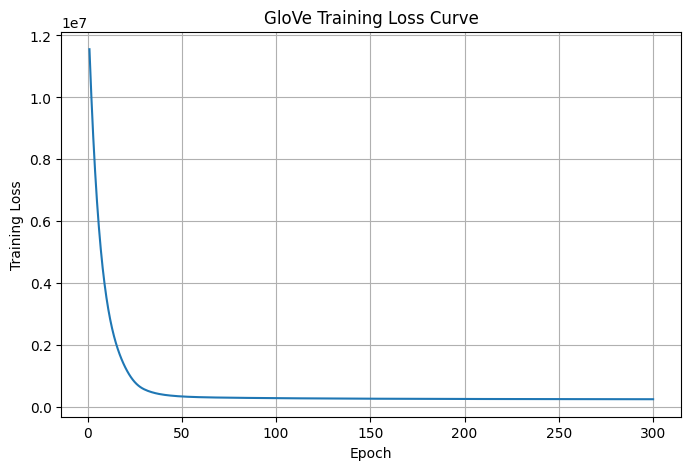

In [ ]:
# @title c6.2 [0pt]
import matplotlib.pyplot as plt

# Plot the losses
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses) + 1), losses)
plt.title("GloVe Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)
plt.show()

<font color="red">**Don't clear the output of the above cell!**</font>

### Validation (Similarity)

Curious to see what this network has learned? Let's perform a simple validation experiment.

We will check which words the model considers the most similar to other words. To that end, we need a notion of __similarity__. One of the most common measures of similarity in high-dimensional vector spaces is the cosine similarity.

The cosine similarity of two vectors $\vec{a}, \vec{b}$ is given as:
$$sim(\vec{a}, \vec{b}) = \frac{\vec{a}\cdot \vec{b}}{|\vec{a}|_2 \cdot |\vec{b}|_2}$$

where $|\vec{x}|_2$ is the $L_2$-norm of the $\vec{x}$.

The function `similarity` below accepts two words, a vocabulary and the network's output vectors, and computes the similarity between these two words. For an outside-vocabulary word similarity is 0.

In [ ]:
from typing import Dict

def similarity(word_i: str, word_j: str, vocab: Dict[str, int], vectors: FloatTensor) -> float:
    # If the word is not in the vocabulary simply return 0
    if word_i not in vocab or word_j not in vocab:
      return 0.
    i, j = vocab[word_i], vocab[word_j]
    v_i = vectors[i] / torch.linalg.vector_norm(vectors[i])  # a/|a|
    v_j = vectors[j] / torch.linalg.vector_norm(vectors[j])  # b/|b|
    sim = torch.dot(v_i, v_j)
    return sim

Let's check out some examples. Consider the word pairs below and, optionally, add your own word pairs if it helps to support your answer:

In [ ]:
word_vectors = network.get_vectors().detach()

for pair in [
    ("cruciatus", "imperius"),
    ("avada", "kedavra"),
    ("hogwarts", "school"),
    ("goblin", "hagrid"),
    ("giant", "hagrid"),
    ("harry", "hermione"),
    ("harry", "albus"),
    ("harry", "dumbledore"),
    ("albus", "quidditch")
]:
    print(f"Similarity between '{pair[0]}' and '{pair[1]}' is: {similarity(pair[0], pair[1], vocab, word_vectors)}")

Similarity between 'cruciatus' and 'imperius' is: 0.4445817470550537
Similarity between 'avada' and 'kedavra' is: 0.5842946767807007
Similarity between 'hogwarts' and 'school' is: 0.7329806089401245
Similarity between 'goblin' and 'hagrid' is: 0.09308719635009766
Similarity between 'giant' and 'hagrid' is: 0.6074062585830688
Similarity between 'harry' and 'hermione' is: 0.905429482460022
Similarity between 'harry' and 'albus' is: 0.09263158589601517
Similarity between 'harry' and 'dumbledore' is: 0.6441073417663574
Similarity between 'albus' and 'quidditch' is: -0.12021966278553009


#### i3 [1pt]
Give an interpretation of the results. Do the scores correspond well to your perceived similarity of these word pairs?

**ANSWER**: <font color="red">YOUR ANSWER HERE</font>

| Cosine similarity | Meaning |
|------------------|---------|
| 1                | Vectors point in exactly the same direction → very similar / aligned |
| 0                | Vectors are orthogonal → no correlation / unrelated |
| -1               | Vectors point in exactly opposite directions → maximally opposite / negatively correlated |

While the thresholds can be adjusted based on the size of the dataset, it is generally accepted that values between 0.5 and 0.7 are **moderately similar**, values above 0.7 indicate **high similarity**, values close to 0 indicate **no relation**, and values closer to -1 indicate that the two words are **opposites**.


* `Cruciatus` and `imperius are two of the three unforgiveable curses. While a value of 0.44 may appear to be too low, it is important to note that similarity here is quantified based on co-occurrences. Therefore, despite the two words being curses, they have very different effects and so often occur in different contexts, so a value close to 0.5 indicating moderate-low similarity may be appropriate.

* Similarly, the third and lethal Unforgivable Curse is made up of two parts: `avada` and `kedavra`. Because the words almost always appear together as a phrase, a moderately high score of around 0.60 is expected; however, some may argue that this value should be even higher given that the two almost always appear together.

* `Hogwarts` is a school, so the high similarity (almost 0.75) is to be expected.

* Because `Hagrid` is a half-giant rather than a goblin, it makes sense that the similarity value between `Hagrid` and the `giant` is relatively high (0.6), whereas the value with the `goblin` is significantly lower, around 0.1, correctly distinguishing between two species.

* `Harry` and `Hermione` are two of Harry Potter's main protagonists. Furthermore, they are both wizards who attend the same school and house, Gryffindor, so the very high similarity (0.90) is also expected.

* The words `Harry` and `Albus` have a value less than 0.1, whereas `Harry` and `Dumbledore` have a value greater than 0.6, which appears strange at first glance, given that Albus Dumbledore is the full name of Hogwarts' headmaster. This disparity can be explained by the fact that the headmaster is much more frequently referred to as Dumbledore rather than Albus. As a result, co-occurrences are generally going to be much higher for the more common word.

* In the final example, two highly unrelated words, `Albus` and `Quidditch`, have a slightly negative value, as expected.

Overall, the cosine similarities correspond well with expectations for our examples of the Harry Potter books, capturing important **semantic relationships** (Harry-Hermione) and **co-occurrence patterns** (Albus vs Dumbledore).



To obtain the similarities of one word against all other words in the corpus, use torch functions and follow the equation ($\vec{c}_i$ is $i$th row of $\mathbf{C}$):
$$sim(\vec{w}, \mathbf{C}) = \frac{\vec{w}\cdot \mathbf{C}}{|\vec{w}|_2 \cdot |\mathbf{C}|_2} = \Big(\frac{\vec{w}\cdot \vec{c}_1}{|\vec{w}|_2 \cdot |\vec{c}_1|_2},\ldots,\frac{\vec{w}\cdot \vec{c}_N}{|\vec{w}|_2 \cdot |\vec{c}_N|_2}\Big)$$

Using `similarity` as a reference, write `similarities`, which accepts one word, a vocabulary and the network's output vectors and computes the similarity between the word and the entire corpus. **If a word is out of vocabulary, it should return a matrix of 0 similarities.**

_Hint_: $\mathbf{C} \in \mathbb{R}^{N, D}$, $\vec{w} \in \mathbb{R}^{1, D}$, $sim(\vec{w}, \mathbf{C}) \in \mathbb{R}^{1, N}$

In [ ]:
# @title c7 [4pt]
def similarities(word_i: str, vocab: Dict[str, int], vectors: FloatTensor) -> FloatTensor:
    # Ensure output uses same device/dtype as vectors
    device = vectors.device
    dtype = vectors.dtype
    N = vectors.size(0)  # number of words

    # OOV -> return row of zeros with shape [1, N]
    if word_i not in vocab:
        return torch.zeros((1, N), device=device, dtype=dtype)

    idx = vocab[word_i]
    # Get word vector as shape [1, D]
    w = vectors[idx].unsqueeze(0)  # (1, D)

    # Dot products: (1, D) @ (D, N) => (1, N)
    dots = torch.matmul(w, vectors.T)  # (1, N)

    # Norms
    w_norm = torch.norm(w, p=2, dim=1, keepdim=True)        # (1, 1)
    C_norms = torch.norm(vectors, p=2, dim=1).unsqueeze(0)   # (1, N)

    # Safeguard for no division with zero
    eps = 1e-8
    sims = dots / (w_norm * C_norms + eps)  # (1, N)

    return sims

In [ ]:
# TEST c7a
assert similarities('harry', vocab, word_vectors).shape == torch.Size([1, len(vocab)])
assert similarities('cow', vocab, word_vectors).shape == torch.Size([1, len(vocab)])

Now we can manipulate the word vectors to find out what the corpus-wide most similar words to a query word are!

In [ ]:
def most_similar(word_i: str, vocab: Dict[str, int], vectors: FloatTensor, k: int) -> List[str]:
    """ Returns a list of k words that are most similar to word_i
        The list excludes word_i itself
    """
    sims = similarities(word_i, vocab, vectors)
    _, topi = sims.topk(dim=-1, k=k+1)
    topi = topi.view(-1).cpu().numpy().tolist()
    inv = {v: i for i, v in vocab.items()}
    return [inv[i] for i in topi if inv[i] != word_i][:k]

In [ ]:
# TEST c7b
for word in [
    "forbidden", "myrtle", "gryffindor", "wand", "quidditch", "marauder",
    "horcrux", "phoenix", "triwizard", "screaming", "letter"
]:
    print(f"Most similar words to '{word}': {most_similar(word, vocab, word_vectors, 6)}")

Most similar words to 'forbidden': ['forest', 'cabin', 'growled', 'scared', 'lights', 'trees']
Most similar words to 'myrtle': ['moaning', 'toilet', 'nice', 'urgently', 'saying', 'ha']
Most similar words to 'gryffindor': ['points', 'stands', 'wood', 'different', 'seeker', 'dean']
Most similar words to 'wand': ['held', 'harry', 'saw', 'vanished', 'like', 'hermione']
Most similar words to 'quidditch': ['team', 'saturday', 'changing', 'practice', 'player', 'season']
Most similar words to 'marauder': ['map', 'invisibility', 'borgin', 'ingredients', 'climbing', 'bothering']
Most similar words to 'horcrux': ['horcruxes', 'destroyed', 'everything', 'tried', 'safe', 'basilisk']
Most similar words to 'phoenix': ['fawkes', 'bird', 'perch', 'feather', 'nowhere', 'form']
Most similar words to 'triwizard': ['tournament', 'task', 'bagman', 'champions', 'thousand', 'ludo']
Most similar words to 'screaming': ['screams', 'echoing', 'piercing', 'gliding', 'fall', 'foot']
Most similar words to 'letter': 

#### i4 [3pt]

Interpret the results in the context of Harry Potter books.
- Do these most similar words make sense (are they actually similar to the query words)?
- Are there any patterns you can see in the "errors" (the words that you wouldn't consider actually similar to the query word in general, in everyday life)?
- Which examples are instances of similarity (if any) and relatedness (if any)?
- Any other observations are welcome.

Illustrate your answers with examples from your model's output.

**ANSWER**: <font color="red">YOUR ANSWER HERE</font>

# Analysis of Most Similar Words in Harry Potter Corpus


| Query Word | Our Notes |
|------------|-----------|
| **forbidden** | Mainly context-**related**: "Forbidden Forest" is a location in Harry Potter. As a result, words like "forest" and "trees" that are very similar here make sense **in the context of Harry Potter** because they are **related**. <br><br> Similarly, other words like "cabin", "growled", and "scared" fit the context of a scary forbidden forest as depicted in the books, so these words are **related**. All of these "most similar" words to "forbidden" would make no sense in real life **outside of the Harry Potter universe**. |
| **myrtle** | "Myrtle," also known as Moaning Myrtle, is a secondary Harry Potter character who appears as a ghost in the books after dying in one of the school's restrooms. <br><br> As such, "moaning" and "toilet" are **related** words that only exist **in the Harry Potter universe**. The remaining words, such as "urgently" or "ha," appear to be **incidental**, with no clear connection to the word "Myrtle". |
| **gryffindor** | "Points" are **related** to "Gryffindor", as the word frequently appears in the context "X points for Gryffindor". Similarly, "seeker" could be considered a **related** word because it refers to a position in quidditch that Gryffindor participates in. <br><br> "Dean" is the final relevant example, as it may reflect the relationship between "gryffindor" and "dean thomas," who was a Gryffindor student. <br><br> Again, all of the above-mentioned **related** words are only **related** **in the context of Harry Potter** and would make no sense in the real world. The remaining words are most likely **incidental** and have no direct relationship to "Gryffindor". |
| **wand** | "Harry" and "Hermione" are two of the series' main wizards, and they, like all other wizards, use wands, so the words are **related**. <br><br> The other words are most likely either words that co-occur in the same context of some spells casted by wands, such as "vanish" or are simply **incidental**. These **related** words would not hold true in the real world. |
| **quidditch** | All of the words "similar" to "quidditch" appear plausible because they are all **related** to the word. <br><br> This only applies to the context of Harry Potter. |
| **marauder** | The word "map" is most relevant because the marauder's map is a significant item in the series. "Invisibility" is also reasonable because the marauder's map can see through people wearing the invisibility cloak, so the two words will most likely appear in **similar** contexts. <br><br> Other words like "climbing" or "bothering" may be **related** to the marauders, who climbed places and possibly bothered people. All of these only make sense **within the context of Harry Potter**. |
| **horcrux** | "Horcruxes" is the plural form of "horcrux" so a high similarity score makes sense. Plural forms can be viewed as **similar** rather than **related**. <br><br> "Basilisk" is a **related** word because basilisks are one of the few creatures capable of destroying horcruxes, so the two words are likely used in **similar** contexts. The remaining words are most likely **incidental**. <br><br> Except for the plural form, these words are only relevant in the context of Harry Potter. |
| **phoenix** | In the Harry Potter series, "Fawkes" refers to a specific phoenix, while "bird" describes the appearance of a phoenix. So, "Fawkes" is **related** because proper nouns (specific instances) are not synonyms, but **related** nouns, and "bird" is **similar** to the word "phoenix". <br><br> In contrast, the words "perch" and "feather" are **related**. The rest is **incidental** or **narrative**. Even **outside of the Harry Potter Universe**, the words "bird," "feather," and "perch" are **similar** or **related** to "phoenix." The term "Fawkes" is only relevant to the series. |
| **triwizard** | The triwizard tournament is a tournament consisting of certain tasks that crowns champions at the end. Thus, "tournament", "tasks", and "champions" are all **related** to "triwizard". <br><br> Ludo Bagman was a judge in the Triwizard tournament, so the words "ludo" and "bagman" are **related**. "Thousand" is **incidental**. The **related** words apply only to the **context of Harry Potter.** |
| **screaming** | "Screams", "echoing", and "piercing" are all **similar** words because they can be used instead of "screaming" in certain contexts. <br><br> The remaining words are most likely **narrative** as we can imagine somebody screaming when they "fall" or are "gliding". The words that are **similar** to "screaming" here would hold in the **outside world** and not just within the context of Harry Potter. |
| **letter** | All of the words in this list are **related** to the word "letter". Some words, such as "sent", "send", "wrote", and "addressed", would also make sense as **related** **outside of the Harry Potter universe**. <br><br> The final two, "owl" and "Hedwig," are exclusive to the Harry Potter series. |



## Observations


1. **Relatedness within Harry Potter context**  
   - The vast majority of words listed as similar are actually related, and this relationship only holds **within the Harry Potter context.**
   - Example: *forbidden* → words like “forest”, “trees”, “vanished”.  


2. **Morphological or proper noun connections**  
   - *horcrux* → “horcruxes” (plural).  
   - *phoenix* → “Fawkes” (proper noun).  


3. **Incidental/less related words**  
   - words like “nice”, “urgently”, “thousand” → are most likely incidental words that are not related with target words.   


4. **Similarity vs. Relatedness**  
   - **Similarity**: same concept/type, e.g., *screaming* → *echoing*, *phoenix* → *bird*.


   - **Relatedness**: co-occurring in context, e.g., *wand* → *held*, *harry*, *hermione*. *forbidden* → *forest*, *trees*.  
Similarity is much less frequent than relatedness in the examples given.


5. **Key takeaways**  
We can clearly see how the model is limited by its own context by seeing “similar” words that would not hold outside of the Harry Potter books, such as forbidden forest that is a place specific to the book series. With that in mind, we can say that:
   - Model captures proper nouns and HP-specific objects well.  
   - Some words are narrative context rather than strict similarity.  
   - Examples like *screaming*, *phoenix* show strong semantic similarity; *wand*, *myrtle*, *forbidden* show context-based relatedness.

Overall it's quite impressive; we managed to encode a meaningful portion of the corpus statistics in only $30$ numbers per word!
(A compression ratio of >99%)

<div class="alert alert-block alert-info">
<b>Note:</b> The word vectors obtained by this process are (to a small extent) random, due to the random initialization of the embedding layers. If you are unhappy with your results, you can repeat the experiment a few times or try to toy around with the hyper-parameters (the smoothing factor of ${X}$, $x_{max}$, $\alpha$, the number of epochs and the dimensionality of the vector space). But do this as your own experiments outside the submission file.
</div>

Word vectors, however, contain way more information than just word co-occurrence statistics. Hold tight until the next assignment, where we will see how word vectors may be used to infer information spanning entire phrases and sentences.

### Validation (Word Analogies)

From the paper:
> The word analogy task consists of questions like "$a$ is to $b$ as $c$ is to __?" To correctly answer this question, we must find the word $d$ such that $w_d \approx w_b - w_a + w_c$ according to the cosine similarity.

Write your own function that performs the word analogy task.  

In addition to the standard approximation $w_d \approx w_b - w_a + w_c$, implement another non-standard but intuitive approximation where we are searching $w_d$ that maximizes the following similarity $w_a - w_b \approx w_c - w_d$.  

Let's see which criteria will give the best results, or maybe both give the same results.    

_Hint_: Take a look at the code a few cells back. Most of what you need is already there.

In [ ]:
import torch
import torch.nn.functional as F

# @title c8 [5pt]

def analogy(
    word_a: str, word_b: str, word_c: str, vocab: Dict[str, int],
    vectors: torch.FloatTensor, k: int = 5, standard: bool = True
) -> List[str]:
    """
    Returns top k words for the analogy task.
    standard=True: uses v_d ≈ v_b - v_a + v_c
    standard=False: uses v_d ≈ v_c - (v_a - v_b)
    """
    # Check if all words exist in vocab
    for w in [word_a, word_b, word_c]:
        if w not in vocab:
            return []

    # Extract vectors
    v_a = vectors[vocab[word_a]]
    v_b = vectors[vocab[word_b]]
    v_c = vectors[vocab[word_c]]

    # The alternative method is NOT just v_c - v_a + v_b (that's the same as standard).
    # Instead, we're doing something different: we want to find a word d where
    # the relationship "a to b" matches the relationship "c to d".
    #
    # Standard: Find the word closest to the vector (v_b - v_a + v_c)
    # Alternative: Find the word d where (v_a - v_b) is most similar to (v_c - v_d)
    if standard:
        solution = v_b - v_a + v_c
        sims = F.cosine_similarity(solution.unsqueeze(0), vectors, dim=1)
    else:
        # Alternative
        relation = v_a - v_b
        # For each word, compute (v_c - that_word) and compare to relation
        differences = v_c.unsqueeze(0) - vectors
        sims = F.cosine_similarity(relation.unsqueeze(0), differences, dim=1)

    # Exclude input words
    for w in [word_a, word_b, word_c]:
        sims[vocab[w]] = -float('inf')

    # Get top k words
    topk = torch.topk(sims, k)
    return [list(vocab.keys())[i] for i in topk.indices]


Some example triplets to test your analogies on:

In [ ]:
# TEST c8
triplets = [("padma", "parvati", "fred"),
            ("avada", "kedavra", "expecto"),
            ("dungeon", "slytherin", "tower"),
            ("scabbers", "ron", "hedwig"),
            ("ron", "molly", "draco"),
            ("durmstrang", "viktor", "beauxbatons"),
            ("snape", "potions", "trelawney"),
            ("harry", "seeker", "ron"),
            # ---------------------
            ("dumbledore", "snape", "harry"),
            ("invisibility", "cloak", "deathly"),
            ("polyjuice", "potion", "felix"),
            # Example that is wrong
            ("harry", "potter", "ron"),
           ]

print("Mode: d ~ c - a + b")
for a, b, c in triplets:
    print("{:^16} is to {:^16} as {:^16} is to\t{}".format(a, b, c, analogy(a, b, c, vocab, word_vectors, 5, standard=True)))

print("\nMode: a - b ~ c - d")
for a, b, c in triplets:
    print("{:^16} is to {:^16} as {:^16} is to\t{}".format(a, b, c, analogy(a, b, c, vocab, word_vectors, 5, standard=False)))

Mode: d ~ c - a + b
     padma       is to     parvati      as       fred       is to	['mouth', 'take', 'promptly', 'eating', 'across']
     avada       is to     kedavra      as     expecto      is to	['patronum', 'stag', 'burning', 'fog', 'focus']
    dungeon      is to    slytherin     as      tower       is to	['keeper', 'hundred', 'heading', 'match', 'gryffindor']
    scabbers     is to       ron        as      hedwig      is to	['time', 'first', 'coming', 'harry', 'perfectly']
      ron        is to      molly       as      draco       is to	['wailed', 'network', 'hepzibah', 'released', 'tortured']
   durmstrang    is to      viktor      as   beauxbatons    is to	['cedric', 'krum', 'ladies', 'party', 'merpeople']
     snape       is to     potions      as    trelawney     is to	['lesson', 'arithmancy', 'divination', 'examination', 'delighted']
     harry       is to      seeker      as       ron        is to	['chasers', 'chaser', 'captain', 'wood', 'score']
   dumbledore    is to

Some minimal emergent intelligence :) *(hopefully..)*. 🧙‍♀️

#### i5 [2pt]

Which analogy equation did give the best results for the provided analogy samples?  

Come up with three additional analogies in the context of Harry Potter.
Add them to the list of analogies in the code above and run the analogy computation.

Interpret the results of the best performing analogy equation (if any):
- For which analogies did the model manage to guess the correct answers (taking the first word in the output to be the model's "guess")?
- For which analogies are the correct answers present in the top K words?
- Do you see any patterns in the cases when the model didn't solve the task correctly? In other words, when the model's guess was wrong, can you suggest why the model guessed what it guessed?

**ANSWER**: <font color="red">YOUR ANSWER HERE</font>

The **first** analogy equation gave the best results for the samples.

The model gave the correct answers for:


*   **avada kadavra** -> **expecto `patronum`**, since both avada kedavra and expecto patronum are two-word spells. As such, the system correctly, predicts the second part of the spell in this case.
*   **invisibility cloak** -> **deathly `hallows`**, since invisibility cloak is a one of the three deathly hallows, alongside the Elder Wand, the Resurrection Stone. Thus, the system predicts hallows, which is semantically perfect.
*   **polyjuice potion** -> **felix `felicis`**. This, again, is correct since the former is a potion that allows a person to temporarily assume the physical appearance of another person and the later is again a potion that makes the drinker very lucky.

The analogies that have the correct answers in the top K words are:


*   **dungeon to slytherin** -> **tower to `gryffindor`**. The dungeon is the common area for Slytherin house, so the analogy seeks the corresponding house for a tower. Gryffindor’s common area is in a tower, making Gryffindor, which is the last answer, the canonically correct answer.
*   **scabbers to ron** -> **hedwig to `harry`**. Scabbers is Ron's pet mice(kinda). Similarly, hedwig is the owl pet of Harry potter. Consequently, Harry, which is the fourth word, is the correct answer.
*   **snape to potions** -> **trelawney to `divination`**. Snape teaches Potions, so the analogous relationship asks what Trelawney teaches. Embeddings suggest divination, which is the third and correct answer.
*   **dumbledore to snape -> harry to `hermione`**. This analogy might seem controversial at first, as some may question whether it is the “correct” answer. However, Dumbledore and Snape shared a close relationship, built on trust and mutual support. By analogy, Harry’s closest and most trusted companion is Hermione. Therefore, we argue that Hermione is the best answer here.


The best guesses are usually done when the semantic relationship is clear, such as two parts of a spell, teacher and subject or owner and pet names. However, many times the guesses are completely wrong. This disparity is most likely caused by the limited dataset that makes inferences about words appearing in similar contexts. For example, Harry is to Potter would expectedly gives us as Ron is to `Weasley` but maybe because ron was often described as nice, curtly or proper, the system believes that when harry is being called Harry potter, Ron is simply called nice or proper rather than by his full name.

Furthermore, when words appear frequently together in text, the model tends to associate them even if the semantic relationship is not correct. This is illustrated by the analogy of Harry is to Seeker as Ron is to ?. Here, the canonically correct answer would be `Keeper`, since this was Ron's position in Quidditch. However, Ron must be appearing in the text alongside Chasers, thus the model predicts `Chasers`, along with other semantically inappropriate words like captain or wood.

The analogy Ron is to Molly as Draco is to ? is about family or guardian relationships. Molly takes care of Ron and sometimes disciplines him, so that’s the connection. The model guessed words like wailed, tortured, or hepzibah, probably because those words appear near Draco the text, but they don’t really capture the desired relationship. For Durmstrang is to Viktor as Beauxbatons is to ?, it’s about school and student. Viktor goes to Durmstrang, so the matching Beauxbatons student would be `Fleur` Delacour, which the model almost got with “ladies”, as Beauxbatons is an all-girls school. These examples show that embeddings often pick words that appear together a lot in the text, even if they don’t really make sense for the investigate relationships.

Another example of this is the first analogy, where the model was unable to predict `George` for Padma is to Parvati as Fred is to ?. This is even weirder because Fred has five more brothers and a sister besides George, but George is the correct answer since Padma and Parvati are twins, just like Fred and George. The model predicted words like “mouth” or “eating,” probably because Fred did a lot of pranks, but it wasn’t able to capture the actual brother relationship.

## Counting co-occurrences

In the beginning of the notebook you were provided with a pickle of co-occurrence counts. But how were these counts obtained?  
You will find this out when you complete this exercise.  

First, we obtain the plain text corpus of the Harry Potter book series and place the book files in the current directory.

In [ ]:
!git clone https://github.com/ErikaJacobs/Harry-Potter-Text-Mining.git

fatal: destination path 'Harry-Potter-Text-Mining' already exists and is not an empty directory.


In [ ]:
!cp Harry-Potter-Text-Mining/Book\ Text/* .

In research, it is relatively common that papers don't include all necessary details for replicating the experiments. This is often due to the lack of space in the paper, overlooking certain details, or simply a bad practice.

We will give you several hints on how the co-occurrence matrix was obtained. With the hints and the provided data in the pickle file, you should be able to replicate the exact content of the co-occurrence matrix from the pickle. Here are the hints:

1.   Tokenization of the data was done in a shallow but effective way: replace all punctuations with white space and delimit tokens on white space;
2.   `nltk` and `string` libraries where used for identifying punctuations and stopwords;
3.   Context windows are symmetric and don't span across chapters (i.e., the last word of chapter $N$ is not co-occuring with the first word of chapter $N+1$).
4.   The vocabulary was obtained based on the frequency cutoff.

How the context words were counted is something you need to find out.  
Remember that the provided pickle file includes a lot of information, so please utilize it wisely.

To replicate the co-occurrence counts, complete the function below. Then use it to find out the exact values of `cutoff` and `window_size` that result in the co-occurrence counts identical to the provided ones. No need to provide the code for finding the exact values. Just use them in the next TEST code cell.

Feel free to import any standard python library. Use the same cell code for importing libraries and defining auxiliary functions (if any).
The code will be evaluated not only on the correctness of the output but also on efficiency. It should be able to extract the counts and create the tensor in less than a minute (in the colab environment).

In [ ]:
# @title c9 [8pt]

import torch
import string
import nltk
from nltk.corpus import stopwords
from collections import Counter
from typing import List
import re
import numpy as np

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def read_book_files(files: List[str], cutoff: int = 10, window_size: int = 20, verbose: bool = False):
    """
    Builds vocabulary, context dictionary, and co-occurrence matrix from book files.

    Args:
        files: list of file paths
        cutoff: frequency threshold for vocab
        window_size: context window size (both sides)
        verbose: print details if True

    Returns:
        voc: dict mapping word -> index
        dd_cnt: nested dict of co-occurrence counts
        X: |vocab| x |vocab| tensor of co-occurrence counts
    """
    all_words = []

    #####################################################
    # Step 1: Read & preprocess
    #####################################################

    for file in files:
        with open(file, 'r', encoding='utf-8') as f:
            # Read the text and lowercase
            text = f.read().lower()

            # Replace any '@' followed by non-space/non-newline characters with a single '@'.
            # This removes section markers like '@3@1' while keeping the '@' as a section separator.
            text = re.sub(r'@[^ \n]*', '@', text)

            # Replace punctuation with spaces, excluding '@' (section separator)
            punctuation_without_at = string.punctuation.replace('@', '')
            translator = str.maketrans(punctuation_without_at, ' ' * len(punctuation_without_at))
            text = text.translate(translator)

            # Tokenize on whitespace
            words = text.split()

            # Remove stopwords
            words = [w for w in words if w not in stop_words]

            # Append the results to all_words
            all_words.append(words)

    #####################################################
    # Step 2: Build vocabulary
    #####################################################

    # Flatten all words, so that word counts can be implemented
    flat_words = [w for book in all_words for w in book]
    word_counts = Counter(flat_words)

    # Keep only frequent words through cutoff, also remove @ (its use is only as a section separator)
    voc_words = sorted([w for w, c in word_counts.items() if c >= cutoff and w != '@'])
    voc = {word: i for i, word in enumerate(voc_words)}

    if verbose:
        print(f"Vocabulary size: {len(voc)}")
        print(f"Example vocab items: {list(voc.keys())[:10]}")

        # Compare with main/reference vocabulary
        same_words = set(voc.keys()) == set(vocab.keys())
        print(f"Vocabularies contain the same words: {same_words}")

    #####################################################
    # Step 3: Filter books to only include words from vocabulary
    #####################################################

    filtered_books = [
        [w for w in book if w in voc or w == '@'] for book in all_words
    ]

    #####################################################
    # Step 4: Build sections using the section separator @, spanning through all the books
    #####################################################

    sections = []
    for book in filtered_books:
        current_section = []
        for w in book:
            if w == '@':
                if current_section:
                    sections.append(current_section)
                    current_section = []
            else:
                current_section.append(w)
        if current_section:
            sections.append(current_section)

    #####################################################
    # Step 5: Build co-occurrence matrix as a numpy array
    #####################################################

    # Initialize co-occurrence matrix
    vocabulary_length = len(voc)
    X_np = np.zeros((vocabulary_length, vocabulary_length), dtype=np.int64)

    # Count co-occurrences within each section
    for section in sections:
        # Convert words to their vocabulary indices
        idxs = [voc[w] for w in section]
        t = np.asarray(idxs, dtype=np.int64)

        # For each distance in the window, count pairs
        for d in range(1, window_size + 1):
            centers = t[d:]      # words 'd' steps ahead
            contexts = t[:-d]    # words 'd' steps behind
            np.add.at(X_np, (centers, contexts), 1)  # left-side counts
            np.add.at(X_np, (contexts, centers), 1)  # right-side counts (symmetry)

    #####################################################
    # Step 6: Final step, convert numpy array to torch tensor and dictionary of contexts
    #####################################################

    X = torch.from_numpy(X_np)
    dd_cnt = {}
    for i, wi in enumerate(voc_words):
        row = X_np[i]
        nz = np.nonzero(row)[0]
        counter_dict = {voc_words[j]: int(row[j]) for j in nz}
        dd_cnt[wi] = Counter(counter_dict)

    if verbose:
        print("Co-occurrence tensor shape:", X.shape)
        print("Number of non-zero co-occurrence entries:", np.count_nonzero(X_np))
        print("\nExample word co-occurrences:")
        for word in list(dd_cnt.keys())[1:4]:  # show 3 example words
            top_contexts = dd_cnt[word].most_common(5)  # top 5 co-occurrences
            print(f"  {word}: {top_contexts}")

    return voc, dd_cnt, X


In [ ]:
# TEST
# Fill in the found cutoff and window_size values
# Cell execution shouldn't take more than 60sec
%%time
my_vocab, my_contexts, my_X = read_book_files([ f"HPBook{n}.txt" for n in range(1,8) ], cutoff=15, window_size=11, verbose = True)

Vocabulary size: 4485
Example vocab items: ['1', 'aback', 'abandoned', 'abbott', 'aberforth', 'ability', 'able', 'abou', 'abrupt', 'abruptly']
Vocabularies contain the same words: True
Co-occurrence tensor shape: torch.Size([4485, 4485])
Number of non-zero co-occurrence entries: 3463070

Example word co-occurrences:
  aback: [('said', 34), ('harry', 30), ('taken', 30), ('looked', 16), ('hermione', 9)]
  abandoned: [('harry', 18), ('said', 15), ('hermione', 10), ('hagrid', 8), ('back', 7)]
  abbott: [('hannah', 15), ('harry', 10), ('said', 8), ('hermione', 7), ('could', 5)]
CPU times: user 3.53 s, sys: 136 ms, total: 3.66 s
Wall time: 3.68 s


In [ ]:
####################################################################################
#           Varius tests, feel free to skip
####################################################################################

# print(X)
# print(contexts['harry'])
# print(my_contexts['harry'])

# # Compare vocabularies
# vocab_set = set(vocab.keys())
# my_vocab_set = set(my_vocab.keys())

# only_in_vocab = vocab_set - my_vocab_set
# only_in_my_vocab = my_vocab_set - vocab_set

# print("Words only in vocab:", only_in_vocab)
# print("Words only in my_vocab:", only_in_my_vocab)

# # Sum of counts in each dictionary
# sum_contexts = sum(contexts['bella'].values())
# sum_my_contexts = sum(my_contexts['bella'].values())

# print(f"Total counts in contexts['harry']: {sum_contexts}")
# print(f"Total counts in my_contexts['harry']: {sum_my_contexts}")

# keys1 = set(contexts['bella'].keys())
# keys2 = set(my_contexts['bella'].keys())

# # Words in contexts but not in my_contexts
# missing_in_mine = keys1 - keys2
# # Words in my_contexts but not in contexts
# extra_in_mine = keys2 - keys1

# print(f"Words missing in my_contexts['bella']: {missing_in_mine}")
# print(f"Extra words in my_contexts['bella']: {extra_in_mine}")

# # Check if all keys are identical
# if keys1 == keys2:
#     print("All keys match!")
# else:
#     print("Keys differ.")

# print('The similarity of the two co-occurence matrices is ' + str(torch.sum(torch.eq(X, my_X)).item()/my_X.nelement()))
# print(my_X)


In [ ]:
# TEST c9
# This makes sure the value types are as expected
assert my_vocab['1'] == 0
assert isinstance(my_vocab, dict)
assert isinstance(my_contexts, dict)
assert 'potter' in my_contexts['harry']
assert isinstance(my_X, torch.Tensor)
assert my_X.size() == (4485,4485)

<font color="red">**Don't clear the output of the above cell!**</font>

#### i6 [1pt]

What are the values of `cutoff` and `window_size` that replicates the provided counts?

Briefly describe the process of finding the correct underlying algorithm of `read_book_files` and the correct values of `cutoff` and `window_size`.  
Be concise. 100-150 words can be more than enough for the description.

To start off, we couldn't replicate the exact co-occurrence matrix. For the parameter values, the `cutoff` that best reproduces the vocabulary is **15**, and the optimal `window_size` is **11**.
To determine the most appropriate window size, we used:

```torch.sum(torch.eq(X, my_X)).item() / my_X.nelement()```


which measures the similarity between the correct co-occurrence matrix and ours.

After preprocessing, we flattened all words and used `Counter` to compute word frequencies. Then, we experimented with different cutoff values to approximate the correct vocabulary size, this was **15**, though we initially found some unwanted tokens like '2' and '3'. Upon further inspection, we discovered that after each chapter there were patterns like `@3@1`, indicating book and chapter numbers. To fix this, we replaced everything after the first `@`, keeping `@` itself as a section separator. This ensured that

> the last word of chapter N is not co-occurring with the first word of chapter N+1.

We tried several approaches to find the correct counting, such as weighting closer context words more heavily, skipping target words not in the vocabulary, and using different window definitions — but none perfectly matched the reference results.

Finally, we reimplemented the sliding window computation using NumPy arrays for improved speed, converting words to indices and efficiently counting co-occurrences at each distance within sections using `np.add.at`, while ensuring symmetry in the co-occurrence matrix. The final step converts the NumPy array into a PyTorch tensor and constructs a context dictionary for each word, allowing us to inspect the most frequent co-occurrences.

### Optional
If you are done, you can continue experimenting in order to understand the system's behaviour better. For example: how does training and hyperparameter choice affect the model's performance?
Repeat the training using your own hyperparameters (vector space dimensionality, optimizer parameters, the number of training epochs, a different random seed, etc.).

During the training loop, print the qualitative benchmarks every few epochs. Do they keep improving? Is there any disadvantage to exhaustively training until convergence?

Now you have all the tools at hand to train the word vectors on any textual corpus.

# <font color="red">Work description</font>

<font color="red">YOUR ANSWER HERE</font>   [100-200 words]

We each worked through all the exercises individually to build a strong understanding of the material. Afterwards, we discussed the more challenging parts together and supported each other throughout the process. Finally, we split the merging task, combining our work from three separate Google Colab notebooks into a single unified one. The most challenging part for us was by far C9, which we got quite close to solving. Its reverse-engineering nature was very intriguing but also quite difficult. Furthermore, the TAs provided valuable feedback and helped us with a particular issue where we didn’t fully understand how the window should span in C9. Last but not least, GenAI assisted us in clarifying certain Python concepts and debugging minor issues in our code. Last but not least, GenAI was very helpful when we needed some cross-validation of our results and in describing certain technical aspects.




# Acknowledgment

The jupyter notebook was initially created by Konstantinos Kogkalidis and Tejaswini Deoskar.  
Recent changes, including adaptation to the Colab environment and the exercise on reconstructing a co-occurrence matrix, are by Lasha Abzianidze.